In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def escalamiento_lineal(x, xmin, xmax):
    x_escalada = xmin + ((x - np.min(x)) / (np.max(x) - np.min(x))) * (xmax - xmin)
    return x_escalada

In [3]:
def estructura_rna(WJI, WKJ, bj, bk, X, activacion="tanh"):
    if activacion == "tanh":
        f_act = lambda a: np.tanh(a)
        f_act_der = lambda a: 1 - np.tanh(a)**2
    elif activacion == "sigma":
        f_act = lambda a: 1 / (1 + np.exp(-a))
        f_act_der = lambda a: np.exp(-a) / (1 + np.exp(-a))**2
    else:
        f_act = lambda a: a
        f_act_der = lambda a: np.ones_like(a)

    aJ = X @ WJI + bj      
    zj = f_act(aJ)         
    Y = zj @ WKJ + bk      

    zj_dev = f_act_der(aJ)

    return Y, zj, zj_dev

In [4]:
# =========================================================
# Datos a entrenar
# =========================================================
NN = 500
t1 = np.linspace(0, 1, NN).reshape(-1, 1)
t2 = np.linspace(-np.pi, np.pi, 500).reshape(-1, 1)
t3 = np.linspace(np.pi / 2, np.pi, 500).reshape(-1, 1)

y = np.exp(t3) * np.cos(t2) * np.sin(2 * np.pi * 2 * t1)
y = y + 0.1 * np.random.randn(*t1.shape)

# Escalamiento lineal
t1 = escalamiento_lineal(t1, -1, 1)
t2 = escalamiento_lineal(t2, -1, 1)
t3 = escalamiento_lineal(t3, -1, 1)
y = escalamiento_lineal(y, -1, 1)

X = np.hstack((t1, t2, t3)) 
T = y                         

In [5]:
# =========================================================
# Estructura de la red neuronal
# =========================================================
input_layer = 3
hidden_layer = 20
output_layer = 1

# Pesos iniciales
np.random.seed(0) 
Wji = np.random.randn(input_layer, hidden_layer)
bj = np.zeros((1, hidden_layer))
Wkj = np.random.randn(hidden_layer, output_layer)
bk = np.zeros((1, output_layer))

# =========================================================
# Parámetros de entrenamiento
# =========================================================
eta = 0.01
epochs = 640000

errors = np.zeros(epochs)

print("Iniciando entrenamiento u optimización por Backpropagation...")

Iniciando entrenamiento u optimización por Backpropagation...


In [6]:
# =========================================================
# Entrenamiento / Backpropagation
# =========================================================
for epoch in range(epochs):
    # Forward: Calulo hacia adelante
    Y, zj, zj_dev = estructura_rna(Wji, Wkj, bj, bk, X, "tanh")

    # Se calcula el error hacia atras
    error = Y - T

    # Backpropagation: Calculo hacia atras
    deltak = error
    gradienteWkj = (zj.T @ error) / NN

    # Delta Capa Oculta
    deltaj = (deltak @ Wkj.T) * zj_dev
    gradienteWji = (X.T @ deltaj) / NN

    # Actualizacion de los pesos con los gradientes
    Wkj = Wkj - eta * gradienteWkj
    bk = bk - eta * np.sum(error, axis=0, keepdims=True) / NN

    Wji = Wji - eta * gradienteWji
    bj = bj - eta * np.sum(deltaj, axis=0, keepdims=True) / NN

    mse = np.mean(error**2)
    errors[epoch] = mse

    if (epoch + 1) % 5000 == 0:
        print(f"Iteración {epoch + 1} - MSE promedio: {mse:.6f}")

# Recalcular salida final con pesos entrenados
Y, _, _ = estructura_rna(Wji, Wkj, bj, bk, X, "tanh")


Iteración 5000 - MSE promedio: 0.090851
Iteración 10000 - MSE promedio: 0.079110
Iteración 15000 - MSE promedio: 0.071662
Iteración 20000 - MSE promedio: 0.066939
Iteración 25000 - MSE promedio: 0.063711
Iteración 30000 - MSE promedio: 0.061305
Iteración 35000 - MSE promedio: 0.059427
Iteración 40000 - MSE promedio: 0.057914
Iteración 45000 - MSE promedio: 0.056654
Iteración 50000 - MSE promedio: 0.055582
Iteración 55000 - MSE promedio: 0.054652
Iteración 60000 - MSE promedio: 0.053825
Iteración 65000 - MSE promedio: 0.053067
Iteración 70000 - MSE promedio: 0.052343
Iteración 75000 - MSE promedio: 0.051624
Iteración 80000 - MSE promedio: 0.050886
Iteración 85000 - MSE promedio: 0.050108
Iteración 90000 - MSE promedio: 0.049279
Iteración 95000 - MSE promedio: 0.048390
Iteración 100000 - MSE promedio: 0.047440
Iteración 105000 - MSE promedio: 0.046428
Iteración 110000 - MSE promedio: 0.045357
Iteración 115000 - MSE promedio: 0.044231
Iteración 120000 - MSE promedio: 0.043050
Iteración 12

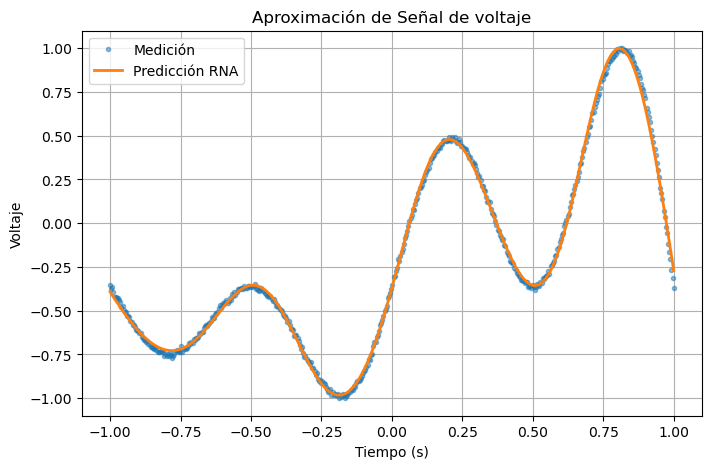

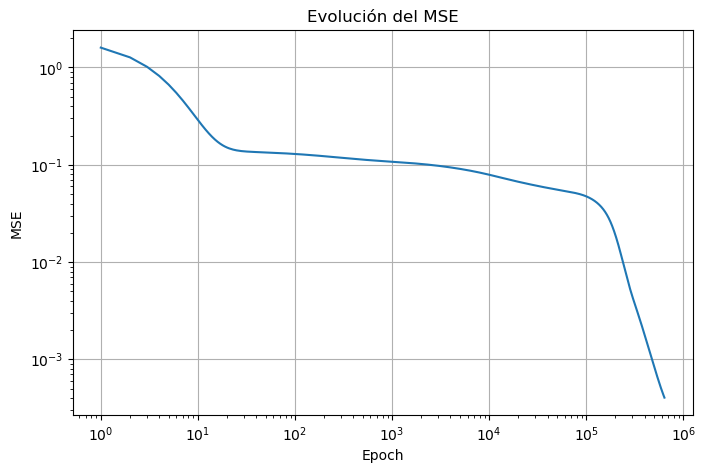

In [9]:
# =========================================================
# Comparación de datos
# =========================================================
plt.figure(figsize=(8, 5), facecolor="white")
plt.plot(t1, y, ".", label="Medición", alpha=0.5)
plt.plot(t1, Y, linewidth=2, label="Predicción RNA")
plt.title("Aproximación de Señal de voltaje")
plt.xlabel("Tiempo (s)")
plt.ylabel("Voltaje")
plt.grid(True)
plt.legend()

plt.figure(figsize=(8, 5))
plt.loglog(np.arange(1, epochs + 1), errors)
plt.grid(True)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Evolución del MSE")

plt.show()